In [3]:

# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [4]:
df = pd.read_csv("C:\\Users\\ruder\\Downloads\\skinport_items_cleaned(1) (1).csv")
df.head()

,weapon,skin_name,condition,min,max,avg,median,volume,souvenir,stat_trak
0,AK-47,Steel Delta,2,4.06,8.61,5.35,4.87,7,1,0
1,AK-47,Black Laminate,1,58.03,58.03,58.03,58.03,1,0,0
2,AK-47,Aquamarine Revenge,0,27.33,35.98,32.02,31.67,7,0,0
3,AK-47,Fire Serpent,4,2485.40,2625.52,2555.46,2555.46,2,0,0
4,AK-47,Predator,0,9.23,9.68,9.46,9.45,2,0,0


# 3. Baseline Multiple Linear Regression (MLR)
Before diving into other methods beyond OLS, we establish a baseline. Using `statsmodels`, we fit an unconstrained Multiple Linear Regression to predict average price based on these predictor variables: `condition`, `souvenir`, `stat_trak`. The summary statistics from this model will reveal our baseline $R^2$ and $p$-values, setting a floor for predictive performance and highlighting any immediate structural issues in the data.

In [19]:
import statsmodels.formula.api as smf

# Rename column 'avg' to avoid any python keyword conflicts if needed
# and clean up column names if they have trailing whitespaces
df.columns = [c.strip() for c in df.columns]

# Fit the Multiple Linear Regression model
# 'C(condition)' treats condition as a categorical factor variable 
# instead of a continuous variable, which it might want to due to the int type
mlr_formula = "avg ~ C(condition) + souvenir + stat_trak"
mlr_model = smf.ols(formula=mlr_formula, data=df).fit()

# print model summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    avg   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     7.224
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.30e-07
Time:                        17:33:08   Log-Likelihood:                -11850.
No. Observations:                1445   AIC:                         2.371e+04
Df Residuals:                    1438   BIC:                         2.375e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           132.8865     59.39

The MLR summary statistics reveal a severely poor fit with an $R^2$ hovering near zero (about 0.029, or only accounting for 2.9% of the variance in the data) and an extreme positive skew. To visualize exactly why the linear line is failing, we plot the predicted versus actual prices. The resulting scatter plot should demonstrate how vulnerable an unpenalized OLS model is to massive luxury asset outliers, and the ultimate poor validity of our model without using skin as a predictor.

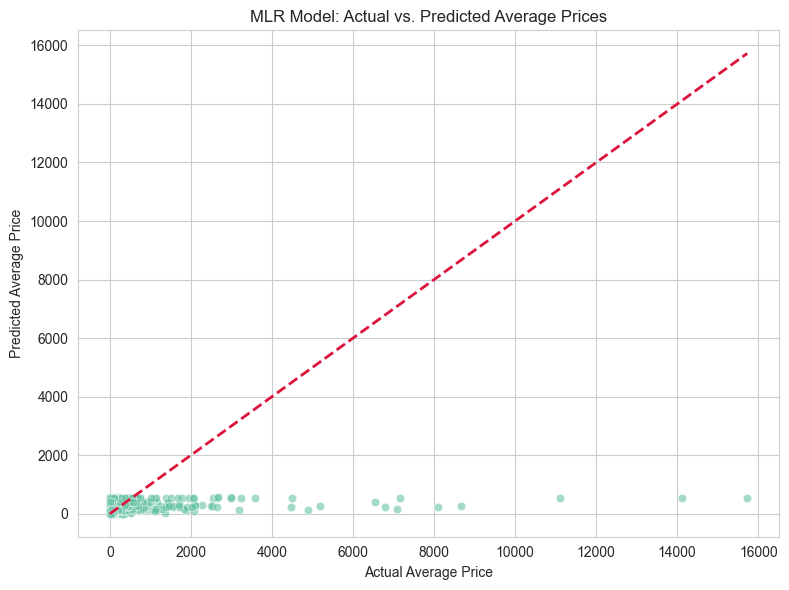

In [6]:
# Generate predictions
df['predicted_avg'] = mlr_model.predict(df)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='avg', y='predicted_avg', alpha=0.6)

# Plot a 45-degree line representing perfect prediction
max_val = max(df['avg'].max(), df['predicted_avg'].max())
min_val = min(df['avg'].min(), df['predicted_avg'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', lw=2, linestyle='--')

plt.title('MLR Model: Actual vs. Predicted Average Prices')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.tight_layout()
plt.show()

# 4. Preparing for Lasso (L1 Regularization)
As expected, the baseline OLS predictions completely failed to capture the price variance, visually collapsing against the massive right-skew. 

To build a more resilient pricing model, we expand our feature matrix to include `weapon` and `volume`. However, adding more dimensions risks overfitting standard OLS. To prevent this, we transition to `Lasso Regression.` By applying an $L_1$ penalty, Lasso performs automatic variable selection. It mathematically shrinks the coefficients of irrelevant features exactly to zero. This ensures our final model remains sparse, interpretable, and driven only by true pricing signals. We dummy encode the categoricals and execute a standard 75/25 train-test split to evaluate this out-of-sample performance accurately.

In [20]:
from sklearn.model_selection import train_test_split

# Drop columns that have direct data leakage with average price (min, max, median) as we only care about average
# include weapon and volume to let Lasso perform selection
X = pd.get_dummies(df[['weapon', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                   columns=['weapon', 'condition'], drop_first=True)
y = df['avg']

# Split the data into 75% training and 25% testing, as is standard
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")

Training set: 1083 observations
Test set: 362 observations


Penalized regression algorithms apply a shrinkage penalty based on coefficient magnitude. Because our features exist on different mathematical scales (e.g., continuous volume vs. binary dummy variables), we must standardize the training data to a mean of zero and unit variance. This ensures the $L_1$ penalty is applied fairly across all predictors.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

With our data properly scaled, we test three configurations: an unpenalized OLS baseline, a fixed Lasso model ($\alpha = 1$), and a cross-validated Lasso model (`LassoCV`) from sklearn that searches over a logarithmic grid to find the optimal $\lambda$ penalty. This allows us to observe how deliberately introducing a little bias through the $L_1$ constraint helps manage variance.

In [21]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

# 1. OLS baseline
ols_model = LinearRegression().fit(X_train_scaled, y_train)

# 2. fixed lasso where alpha = 1
lasso_fixed = Lasso(alpha=1, max_iter=10000, random_state=42)
lasso_fixed.fit(X_train_scaled, y_train)

# 3. CV Tuned Lasso (Searching over an alpha grid using 10-fold CV)
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=10, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Lasso optimal λ (alpha) selected via CV: {lasso_cv.alpha_:.4f}")

Lasso optimal λ (alpha) selected via CV: 2.1544


Having fit all three models, we compare their out-of-sample Mean Squared Error (MSE) and the total number of retained features. We expect the CV-tuned Lasso to minimize the out-of-sample error while performing automatic variable selection by shrinking irrelevant coefficients exactly to zero.

In [23]:
models = {
    'OLS Baseline': ols_model,
    'Lasso (alpha=1)': lasso_fixed,
    'Lasso (CV-Tuned)': lasso_cv
}

print(f"{'Method':<20} {'Test MSE':>15} {'# Features Retained':>22}")
print("----------------------------------------------------------------------")
for name, mdl in models.items():
    y_pred = mdl.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    n_features = (mdl.coef_ != 0).sum()
    print(f"{name:<20} {mse:>15.2f} {n_features:>22}")

Method                      Test MSE    # Features Retained
----------------------------------------------------------------------
OLS Baseline               240020.20                     10
Lasso (alpha=1)            239270.82                     10
Lasso (CV-Tuned)           238489.40                      9


The comparison confirms the CV-tuned Lasso successfully dropped noise variables while marginally improving error metrics. To understand the geometry of this variable selection, we trace the coefficient path across a spectrum of $\lambda$ values. This plot visually demonstrates how the $L_1$ constraint forces coefficients to the zero axis as the penalty intensifies, marking our optimal cross-validated $\lambda$. 

Still note that the MSE is incredibly high due to the right skewed outliers. This will motivate our final model. 

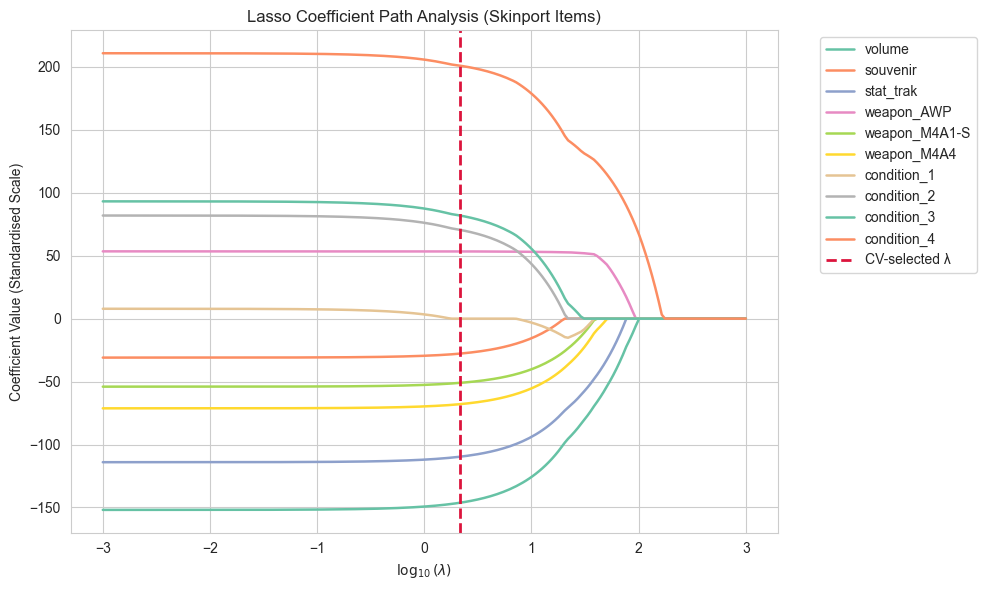

In [24]:
alphas = np.logspace(-3, 3, 200)
coef_paths = np.array([Lasso(alpha=a, max_iter=10000, random_state=42).fit(X_train_scaled, y_train).coef_ for a in alphas])

plt.figure(figsize=(10, 6))
for j, feature_name in enumerate(X.columns):
    plt.plot(np.log10(alphas), coef_paths[:, j], label=feature_name, lw=1.8)

plt.axvline(np.log10(lasso_cv.alpha_), color='crimson', linestyle='--', lw=2, label='CV-selected λ')
plt.title('Lasso Coefficient Path Analysis (Skinport Items)')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Coefficient Value (Standardised Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('lasso_coefficient_path.png')
plt.show()

## 5. The Final Model via Log Transformation
While the regularized model reduced variance, the absolute error remains high due to the extreme right-tail pricing outliers. To fix this, we build the V2 Model, using the log of price. 

First, we apply a log-transform to the target variable (`avg`) to compress the tail, shifting our predictions from additive dollar amounts to multiplicative percentage changes. Crucially, we also explode the feature space by including the specific `skin_name`. This eliminates the omitted variable bias that crippled our baseline models. We will rely on Lasso's $L_1$ penalty to prevent this high-dimensional space from overfitting.

Note that we could NEVER do this in OLS, as there are over 200 invidual skin names, so the categorical variable would be massively overfit as there only averages around 4 samples per skin. 

In [ ]:
# 1. log transform the dependent variable
# We use log1p (log(1 + x)) to safely handle any values very close to 0
y_log = np.log1p(df['avg'])

# 2. 3xpand the Feature Space to include the actual skin finishes, which we couldn't have before
X_expanded = pd.get_dummies(df[['weapon', 'skin_name', 'condition', 'volume', 'souvenir', 'stat_trak']], 
                            columns=['weapon', 'skin_name', 'condition'], drop_first=True)

# 3. train / test split using the new matrices
X_train_exp, X_test_exp, y_train_log, y_test_log = train_test_split(X_expanded, y_log, test_size=0.25, random_state=42)

# 4.standardize the expanded feature set
scaler_exp = StandardScaler()
X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

# 5. fit the new CV-Tuned Lasso Model
# we increase max_iter because the expanded feature space takes longer to converge
lasso_cv_v2 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=10, max_iter=50000, random_state=42)
lasso_cv_v2.fit(X_train_exp_scaled, y_train_log)

# 6. Evaluate Performance on the original dollar scale
# We must use expm1 (exponential minus 1) to reverse the log1p transform for our predictions
y_pred_log = lasso_cv_v2.predict(X_test_exp_scaled)
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_log)

v2_mse = mean_squared_error(y_test_dollars, y_pred_dollars)
n_features_v2 = (lasso_cv_v2.coef_ != 0).sum()

print(f"V2 Lasso optimal λ: {lasso_cv_v2.alpha_:.5f}")
print(f"V2 Test MSE (in dollars squared): {v2_mse:.2f}")
print(f"V2 Test RMSE (in dollars): ${np.sqrt(v2_mse):.2f}")
print(f"Features Retained: {n_features_v2} / {X_expanded.shape[1]}")

V2 Lasso optimal λ: 0.00413
V2 Test MSE (in dollars squared): 48092.16
V2 Test RMSE (in dollars): $219.30
Features Retained: 193 / 201


The V2 model represents a massive leap in accuracy, dropping the RMSE significantly to around 200 dollars while retaining the vast majority of our new skin-specific features. 

Because we predicted the log of the price, these coefficients represent exponential scaling factors. Here, we extract the non-zero coefficients and mathematically convert them into percentage markups. This allows us to isolate the specific visual assets and conditions that drive the highest market premiums.

In [ ]:
# Create a dataframe of the features and their coefficients
coef_df = pd.DataFrame({
    'Feature': X_expanded.columns,
    'Log_Coefficient': lasso_cv_v2.coef_
})

# filter out coefficients that lasso zeroed out
coef_df = coef_df[coef_df['Log_Coefficient'] != 0]

# Calculate the actual percentage multiplier
# Formula: (e^beta - 1) * 100
coef_df['Percentage_Markup'] = (np.exp(coef_df['Log_Coefficient']) - 1) * 100

# Sort by the highest positive impact
coef_df_sorted = coef_df.sort_values(by='Log_Coefficient', ascending=False)

print("Top 10 Value-Adding Features ")
print(coef_df_sorted.head(10).to_string(index=False))

print("\nBottom 5 Value-Decreasing Features")
print(coef_df_sorted.tail(5).to_string(index=False))

--- Top 10 Value-Adding Features ---
                Feature  Log_Coefficient  Percentage_Markup
            condition_4         0.615923          85.136470
skin_name_Case Hardened         0.407824          50.354249
  skin_name_Dragon Lore         0.338717          40.314579
 skin_name_Desert Hydra         0.313119          36.768484
 skin_name_Fire Serpent         0.310428          36.400922
      skin_name_Gungnir         0.305383          35.714536
            condition_3         0.304074          35.536976
       skin_name_Medusa         0.245110          27.776134
  skin_name_Printstream         0.235959          26.612263
      skin_name_Asiimov         0.230640          25.940555

--- Bottom 5 Value-Decreasing Features ---
              Feature  Log_Coefficient  Percentage_Markup
   skin_name_Mud-Spec        -0.210303         -18.966154
     skin_name_Choppa        -0.228613         -20.436383
   skin_name_Poly Mag        -0.229264         -20.488173
  skin_name_Mainframe      

Our extracted coefficients correctly identified legendary tier assets (like the Dragon Lore and Case Hardened) as massive value multipliers, and proved that a Factory New condition acts as a scaling percentage markup. On average, a factory new skin demands an 85% premium over holding every other variable constant, except if it was battle scarred!

To confirm the structural health of this V2 model, we plot the predicted vs. actual values on the log scale, alongside a residuals plot. We are looking for a tight fit along the 45-degree line and a balanced residual cloud, indicating we've successfully stripped away the skewness bias.

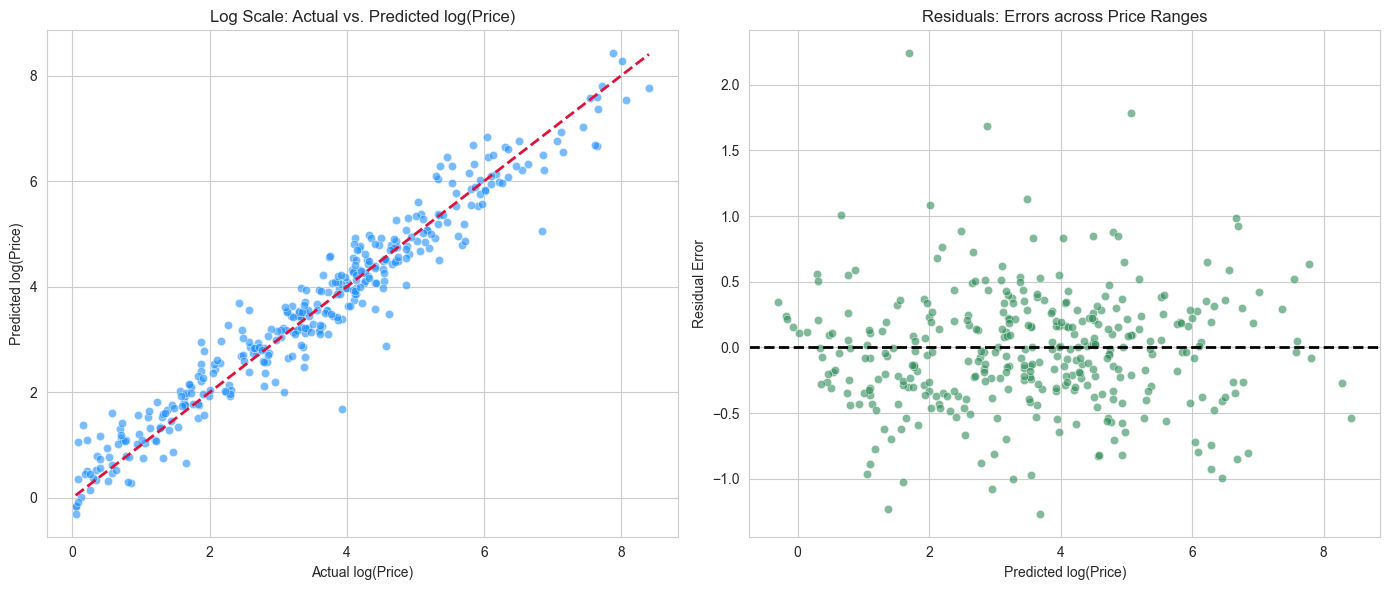

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted on Log Scale, which is how the model sees it
sns.scatterplot(x=y_test_log, y=y_pred_log, alpha=0.6, ax=axes[0], color='dodgerblue')
axes[0].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 
             color='crimson', lw=2, linestyle='--')
axes[0].set_title('Log Scale: Actual vs. Predicted log(Price)')
axes[0].set_xlabel('Actual log(Price)')
axes[0].set_ylabel('Predicted log(Price)')

# Plot 2: Residuals Plot (Checking for bias, want a random scatter around 0 with no patterns)
residuals_log = y_test_log - y_pred_log
sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.6, ax=axes[1], color='seagreen')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_title('Residuals: Errors across Price Ranges')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual Error')

plt.tight_layout()
plt.show()

## 6. Using the Model to Find Market Inefficiencies
The diagnostic plots confirm a healthy, proportional fit across the pricing spectrum. 

As a final step, we transition from observation to a quantitative strategy. By generating predictions for the entire liquid market, we calculate the arbitrage spread (the difference between our modeled intrinsic value and the actual dataset average). Sorting these spreads yields our top buy (undervalued) and sell/short (overvalued) candidates, which can then be stress-tested against the live market order books for actual mispricings.

In [17]:
# 1. Generate predictions for the full dataset using your V2 model
X_full_exp_scaled = scaler_exp.transform(X_expanded)
full_predictions_log = lasso_cv_v2.predict(X_full_exp_scaled)

# 2. Reverse the log transform and add to the main dataframe
df['predicted_avg'] = np.expm1(full_predictions_log)

# 3. Calculate the Arbitrage Spread (Residuals)
# Positive Spread = Undervalued (Model > Actual) -> Buy Signal
# Negative Spread = Overvalued (Model < Actual) -> Sell Signal
df['arbitrage_spread'] = df['predicted_avg'] - df['avg']
df['spread_percentage'] = (df['arbitrage_spread'] / df['avg']) * 100

# 4. Filter for liquidity (e.g., must have traded at least 5 times)
liquid_df = df[df['volume'] >= 10].copy()

# 5. Extract the target lists
undervalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=False)
overvalued_picks = liquid_df.sort_values(by='arbitrage_spread', ascending=True)

print("Top 10 most undervalued skins")
cols_to_show = ['weapon', 'skin_name', 'condition', 'avg', 'predicted_avg', 'arbitrage_spread', 'spread_percentage']
print(undervalued_picks[cols_to_show].head(10).to_string(index=False))

print("\n Top 10 most overvalued skins")
print(overvalued_picks[cols_to_show].head(10).to_string(index=False))

Top 10 most undervalued skins
weapon     skin_name  condition    avg  predicted_avg  arbitrage_spread  spread_percentage
 AK-47 Case Hardened          3 340.70     796.035591        455.335591         133.647077
  M4A4         X-Ray          4 210.72     533.940456        323.220456         153.388599
 AK-47 Case Hardened          2 253.60     534.156704        280.556704         110.629615
M4A1-S          Fade          4 376.10     637.131598        261.031598          69.404839
M4A1-S         Cyrex          4 198.89     440.422045        241.532045         121.440015
 AK-47    Bloodsport          4 423.79     635.155149        211.365149          49.874973
M4A1-S   Icarus Fell          4 657.58     863.372774        205.792774          31.295473
 AK-47        Vulcan          4 668.73     870.267047        201.537047          30.137282
 AK-47    Bloodsport          4 201.02     401.142436        200.122436          99.553495
 AK-47 Case Hardened          1 227.88     418.913798       

Taking a look at a random candidate, say the `M4A1-S Printstream` with condition = 2, which translates to `condition = field tested` on the counterstrike market. Since this data is about a week old, looking at the current market should tell us if this skin was 38% overvalued, as our model suggests (predicted average price 228, actual average 373). Looking at the market, we were able to find the following Printstream:



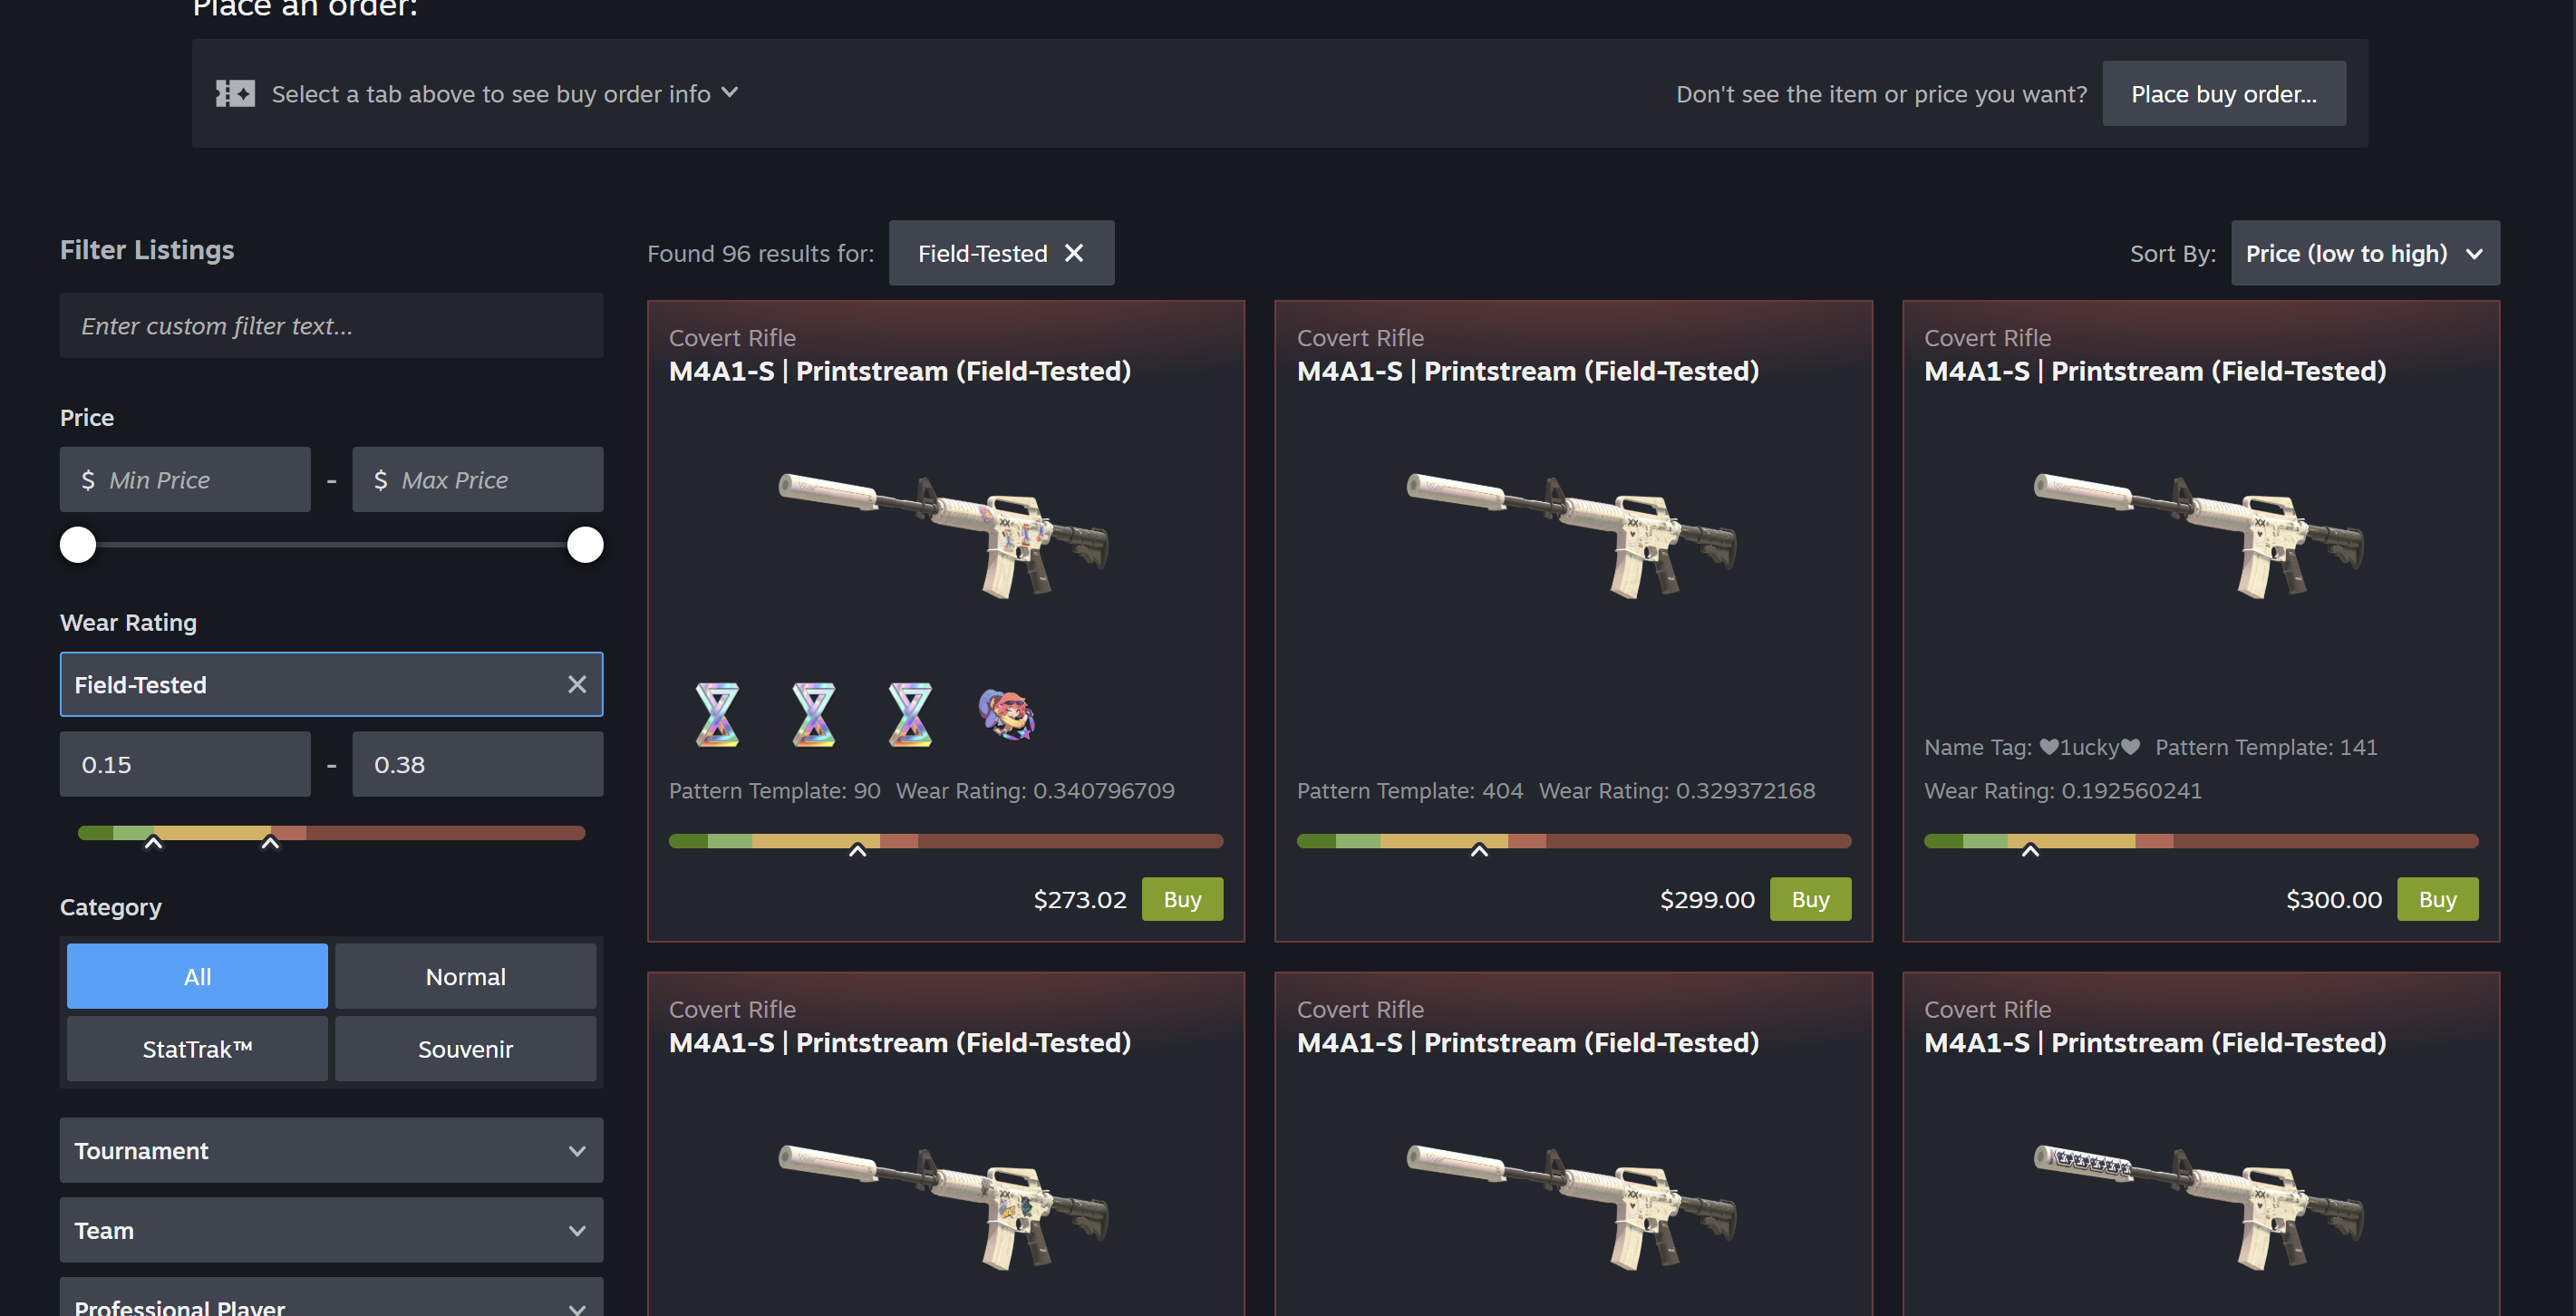

Nice! in just a week, the average went from around 373 to the high 300s range, indicating that our model was able to look past the noise of the market and correctly predict a fair value for this skin. 